In [7]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.diagnostic import het_white
import statsmodels.api as sm
from statsmodels.formula.api import ols

Bivariate: 
1. Numeric to numeric: Correlation
2. Numeric to categorical: One-way ANOVA (3+ groups) or t-test (2 groups)
3. Categorical to categorical: Chi square

In [8]:
df = pd.read_csv("data/train.csv")
df.dropna(axis=1, inplace=True)

Step 1. Use the unique() func. to generate a list of the unique values in this categorical column

Step 2. Use the groupby() func. to sort the DataFrame by the current categorical column

Step 3. Make an empty list that will be a two-dimensional list of lists to store the label values associated with each category

Step 4. Loop through the unique category values

Step 5. Use the get_group() func. to return a list containing only the records for each unique value

Step 6. Use the append() func. to store the list of label values made in the prior step into our list-of-lists

In [9]:
def anova(df, feature, label):
    # Determine what the feature and label is. 
    
    groups = df[feature].unique() 
    
    df_grouped = df.groupby(feature) 
    
    group_labels = [] 
    
    for g in groups:
        g_list = df_grouped.get_group(g)
        
        group_labels.append(g_list[label])
        
    return stats.f_oneway(*group_labels)

In [10]:
def bivstats(df, label):
    # Make an empty DataFrame to store the results
    output_df = pd.DataFrame(columns=["r", "F", "Chi2", "p-value"])
    
    for col in df: # Use this to loop through the insurance DataFrame
        if not col == label:
            if df[col].isnull().sum() == 0:
                if pd.api.types.is_numeric_dtype(df[col]): # Only calculate from the numeric columns
                    r, p = stats.pearsonr(df[label], df[col])
                    output_df.loc[col] = [round(r, 4), np.nan, np.nan, round(p, 4)]
                    scatter(df, col, label)
                else:
                    F, p = anova(df[[col, label]], col, label)
                    output_df.loc[col] = [np.nan, round(F, 4), np.nan, round(p, 4)]
            else:
                output_df.loc[col] = [np.nan, np.nan, np.nan, np.nan]
            
    return output_df.sort_values(by=["r"], ascending=False)

In [11]:
def heteroscedasticity(df, feature, label):
    model = ols(formula=(f"{label}~Q('{feature}')"), data=df).fit()

    white_test = het_white(model.resid, model.model.exog)
    bp_test = het_breuschpagan(model.resid, model.model.exog)

    output_df = pd.DataFrame(columns=["LM stat", "LM p-value", "F-stat", "F p-value"])
    output_df.loc["White"] = white_test
    output_df.loc["Br-Pa"] = bp_test

    return output_df.round(3)

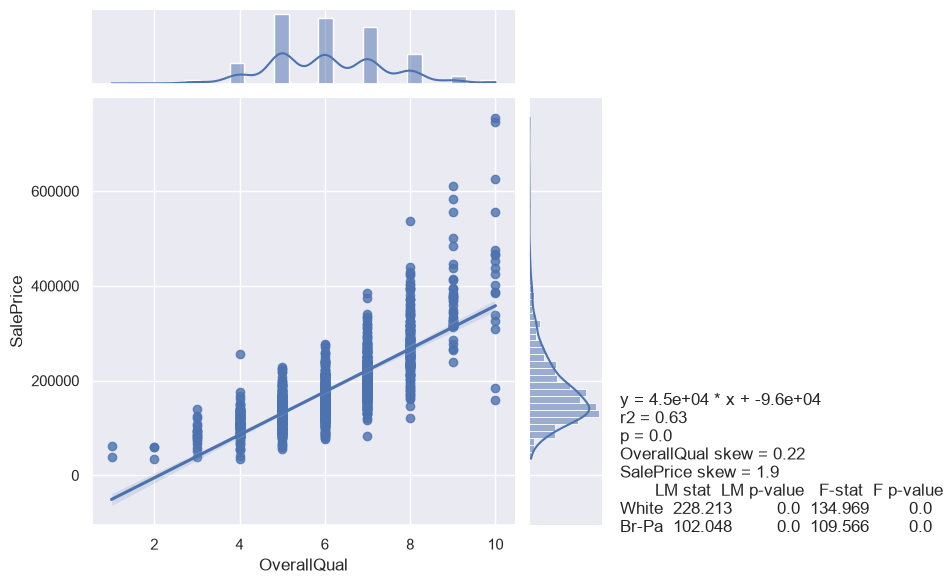

In [12]:
def scatter(df, feature, label):
    # Calculate the regression line
    m, b, r, p, err = stats.linregress(df[feature], df[label])

    textstr = f"y = {m:.2} * x + {b:.2} \n"
    textstr += f"r2 = {r**2:.2} \n"
    textstr += f"p = {p:.2} \n"
    textstr += f"{feature} skew = {df[feature].skew():.2} \n"
    textstr += f"{label} skew = {df[label].skew():.2} \n"
    textstr += f"{str(heteroscedasticity(df, feature, label))}"
    #plt.text(1, 0.1, textstr, fontsize=12, transform=plt.gcf().transFigure)
    
    sns.set(color_codes=True);
    ax = sns.jointplot(data=df, x=feature, y=label, kind="reg");
    ax.fig.text(1, 0.1, textstr, fontsize=12, transform=plt.gcf().transFigure);
    
scatter(df, "OverallQual", "SalePrice")

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:1696: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  f = plt.figure(figsize=(height, height))


AssertionError: 

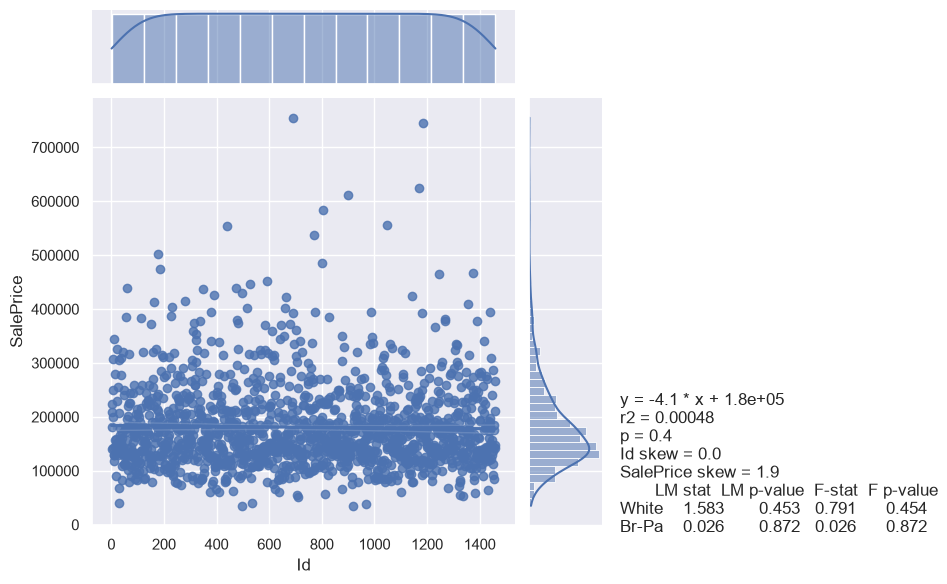

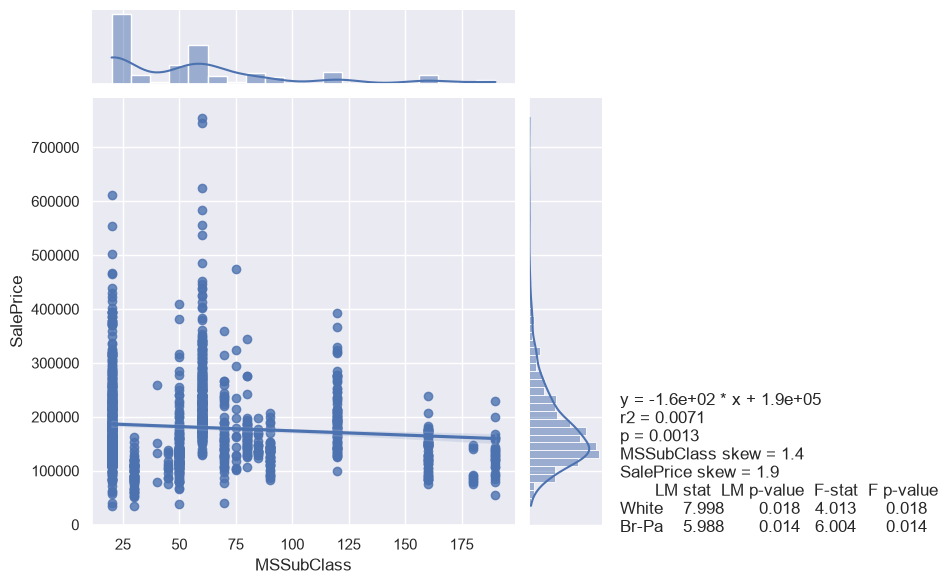

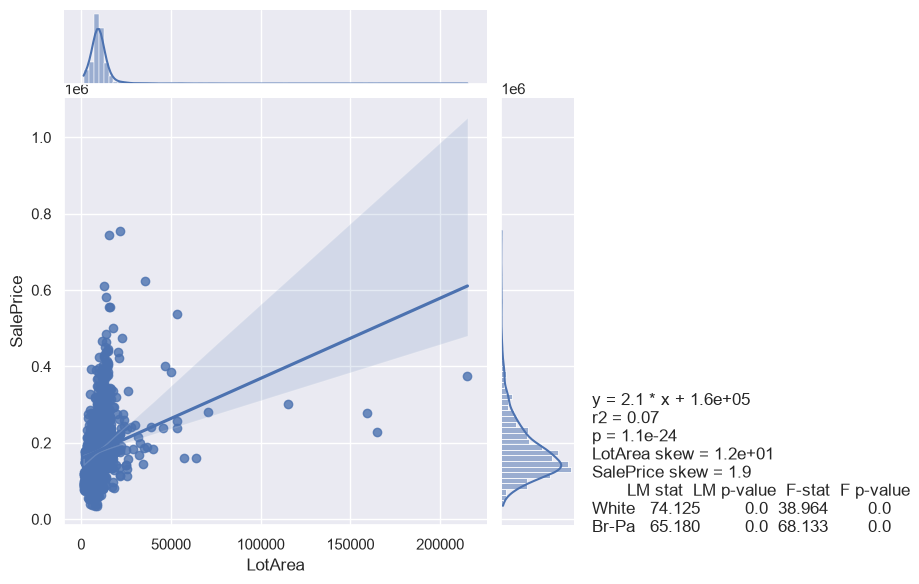

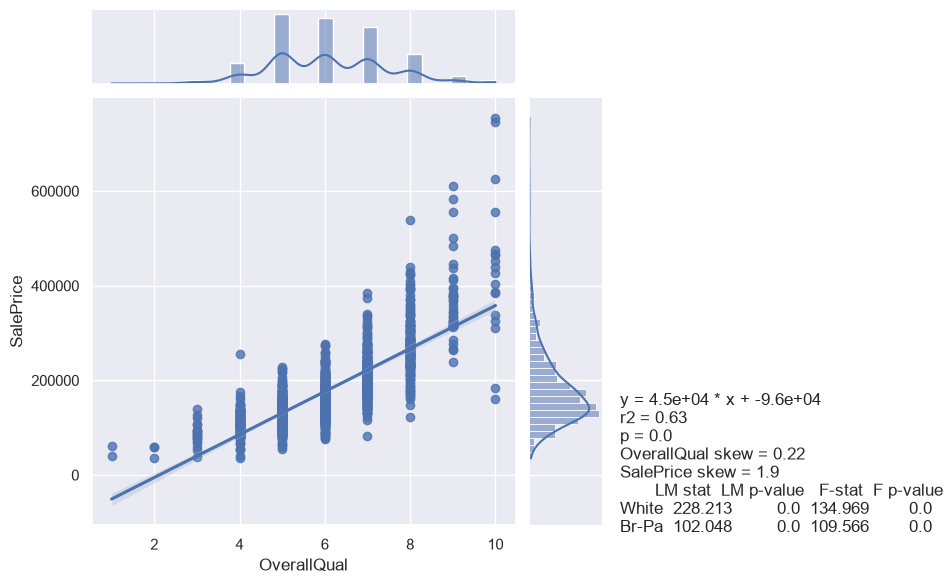

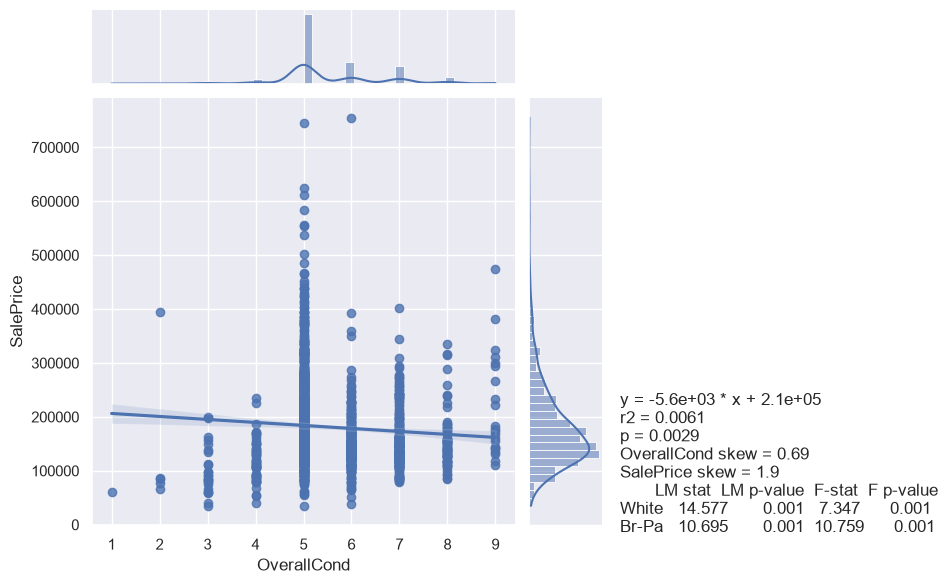

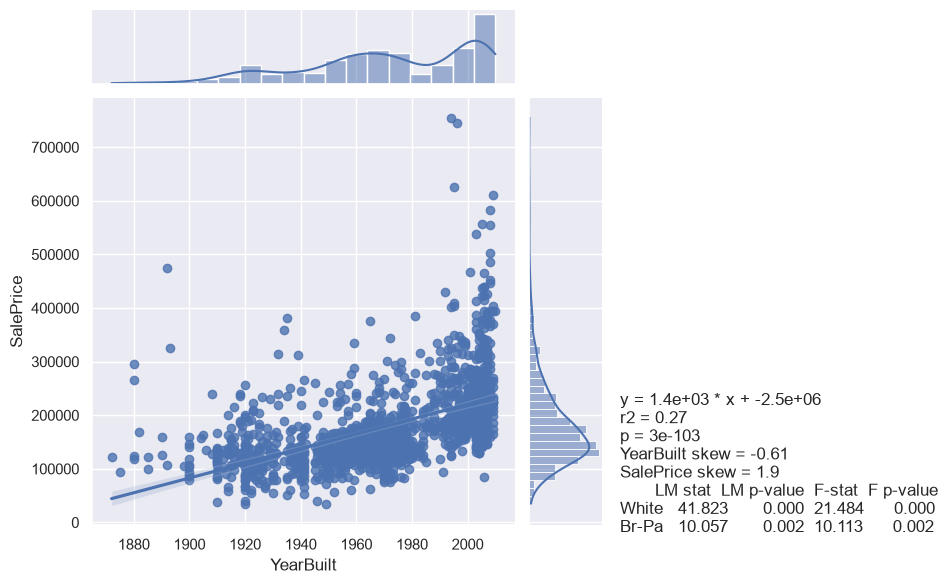

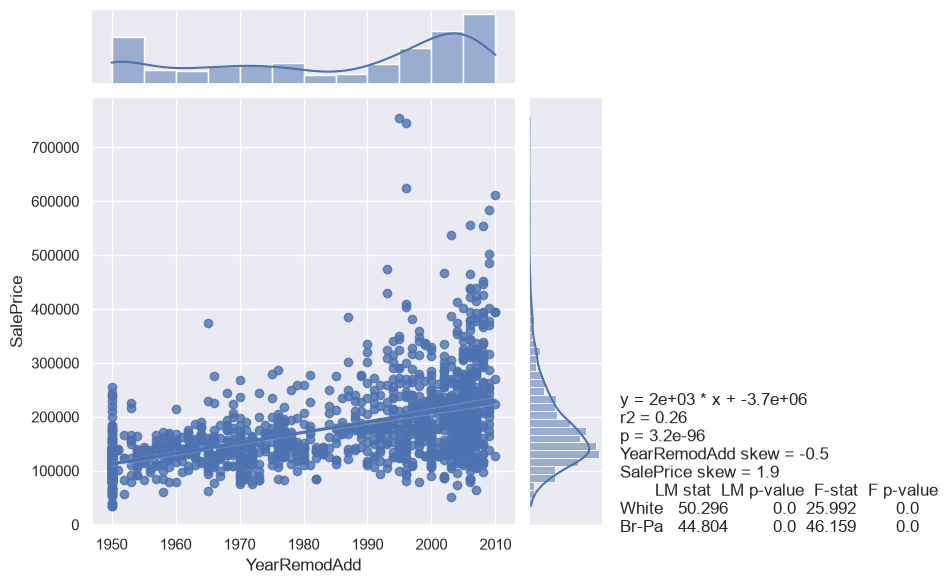

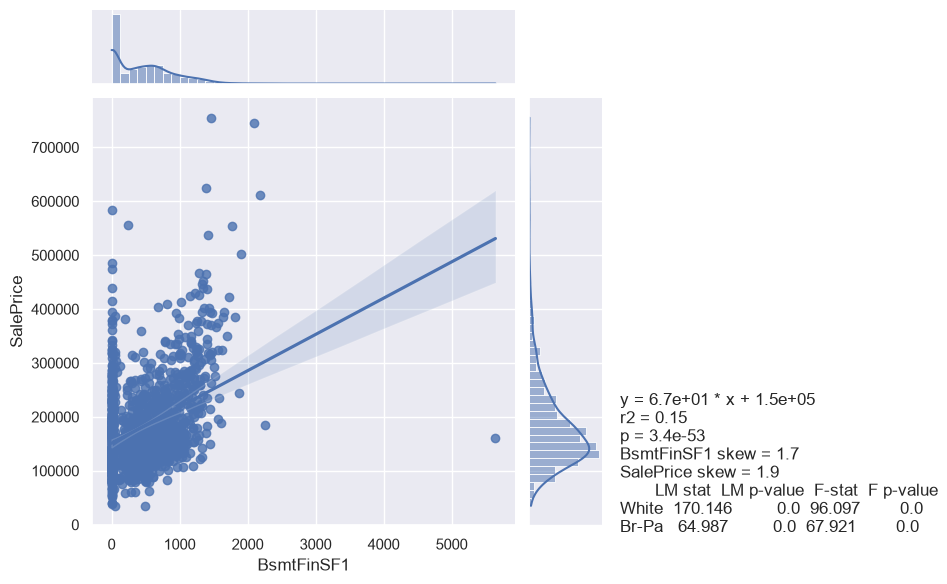

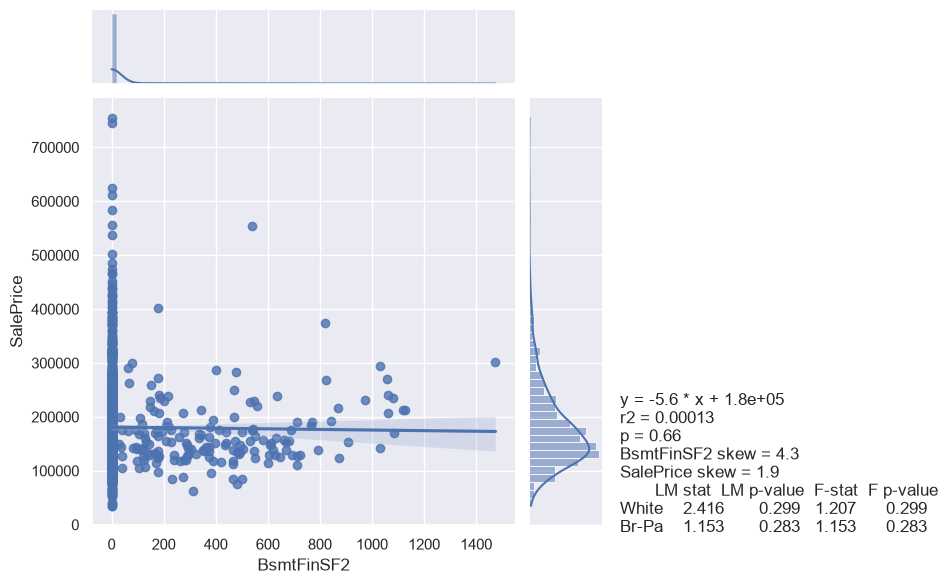

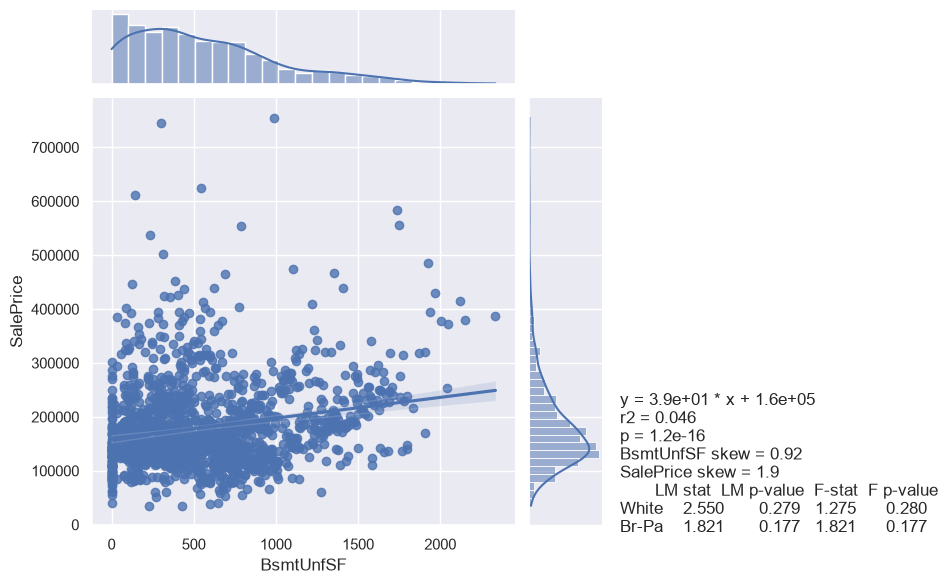

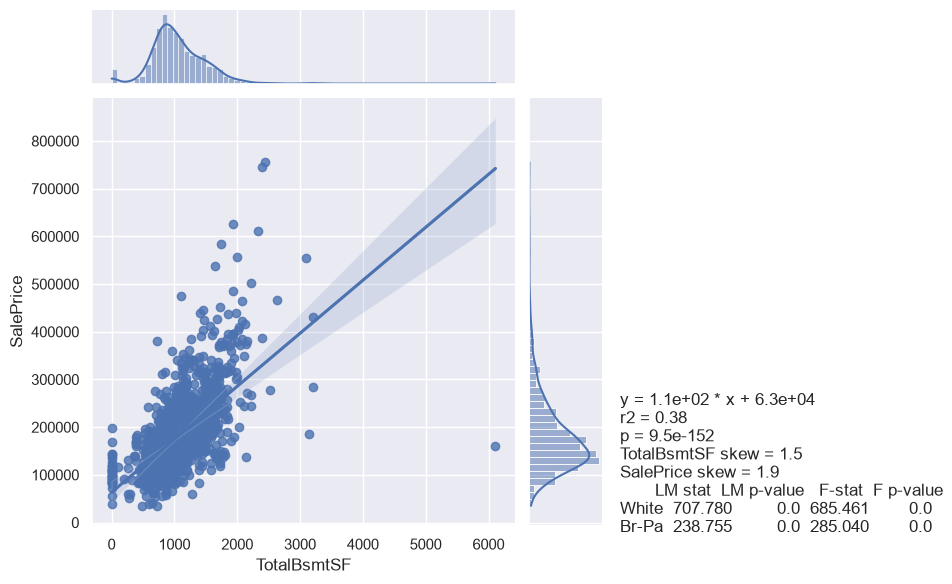

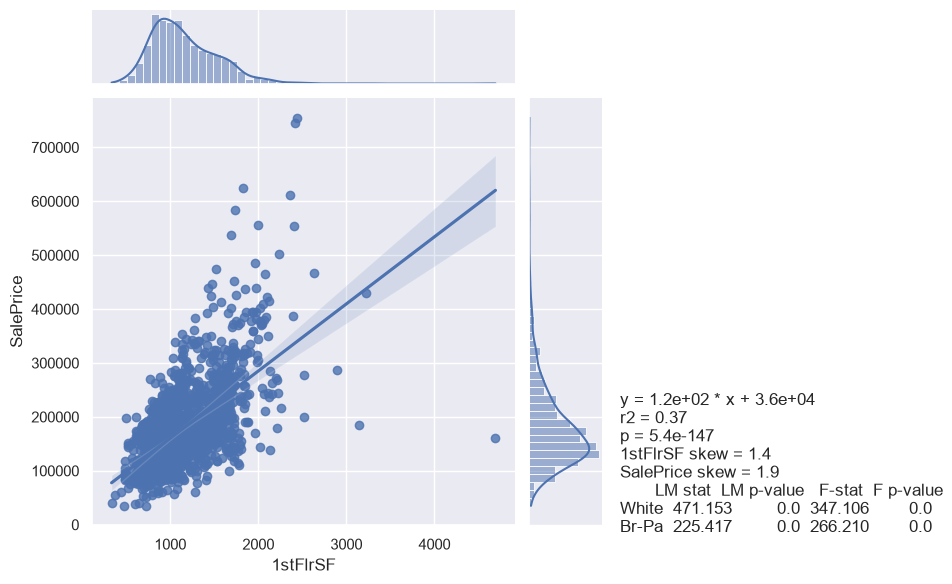

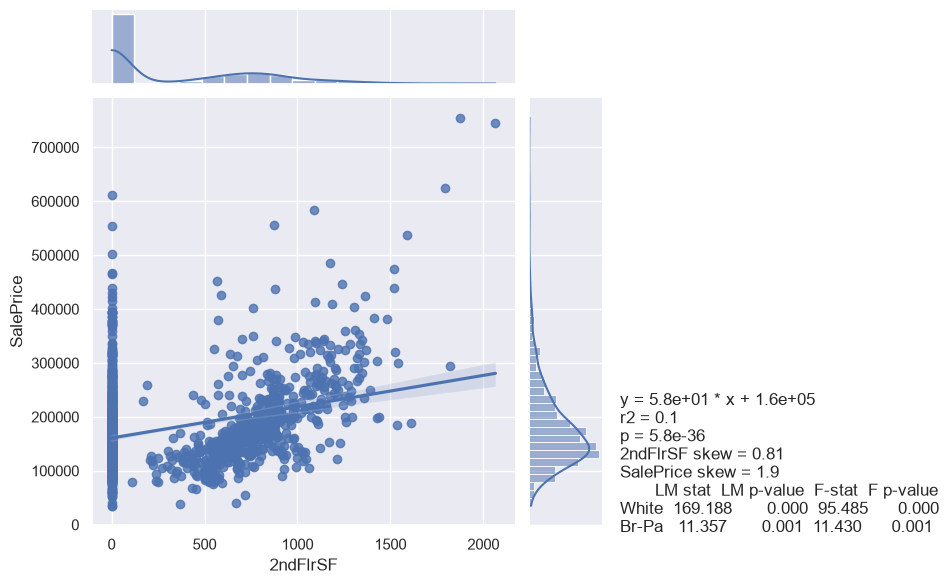

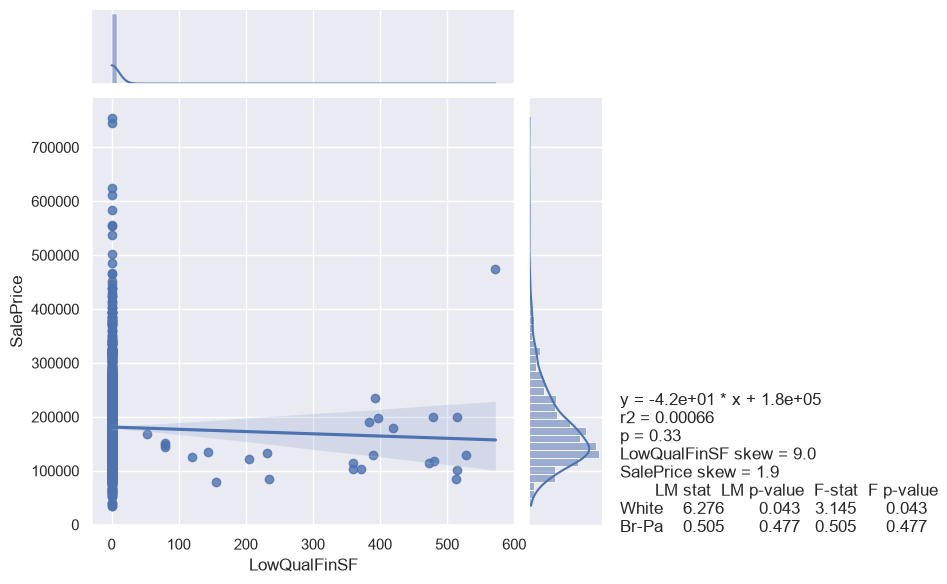

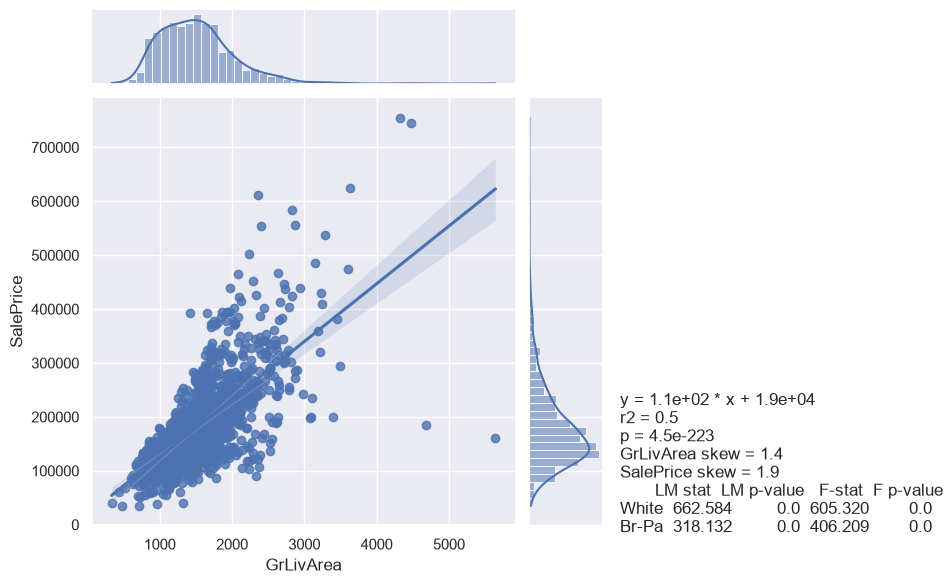

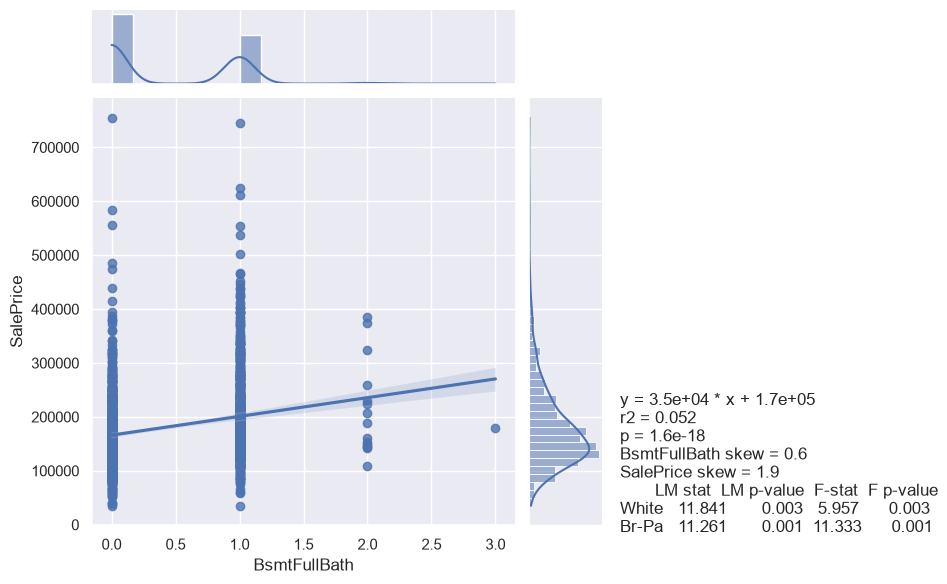

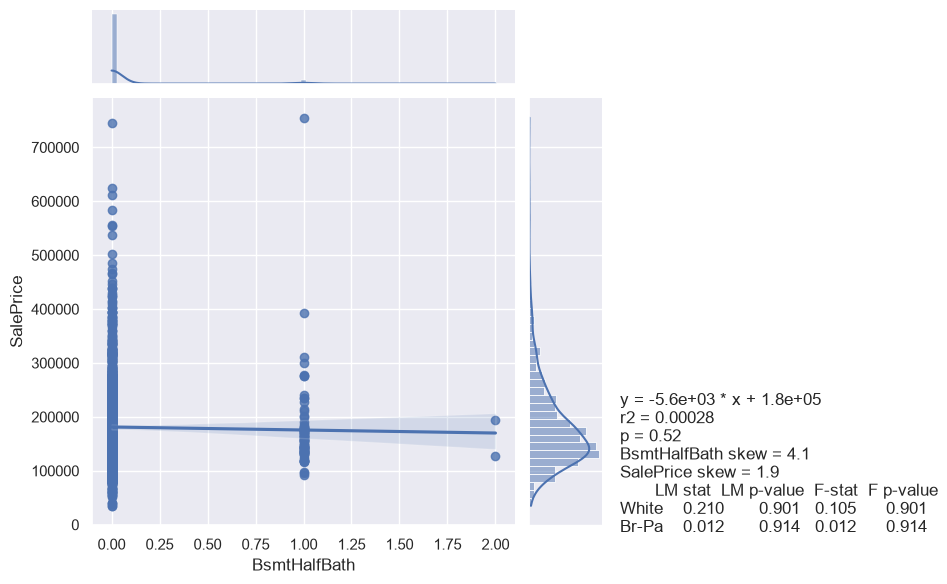

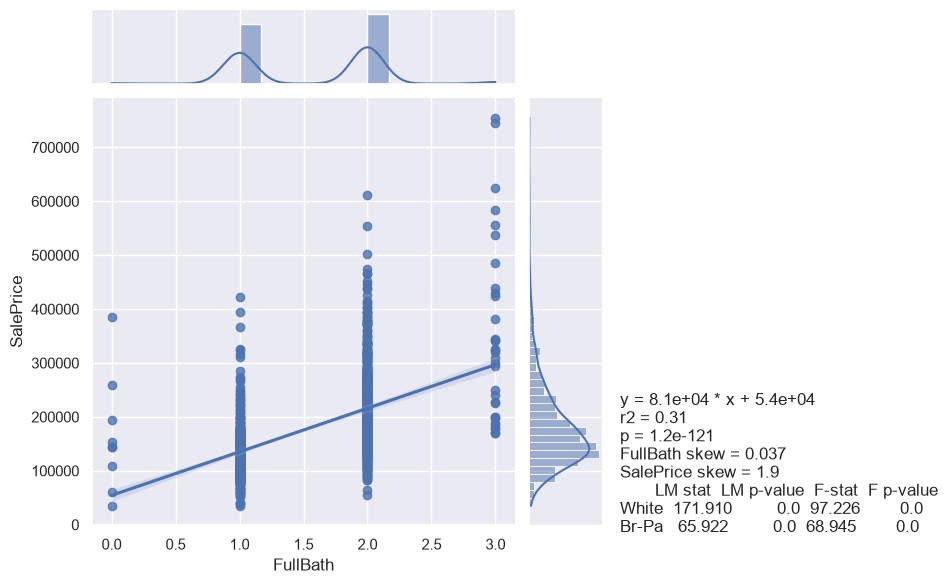

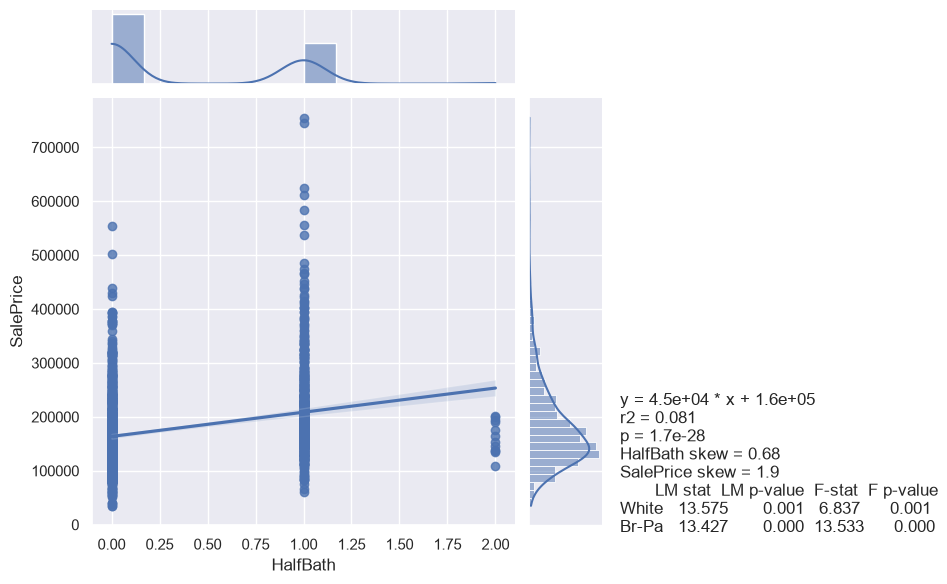

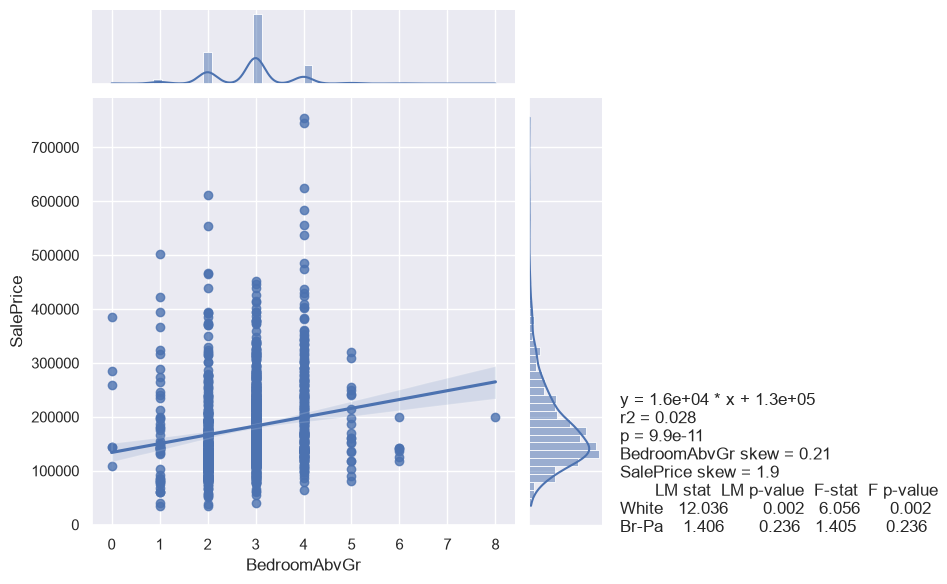

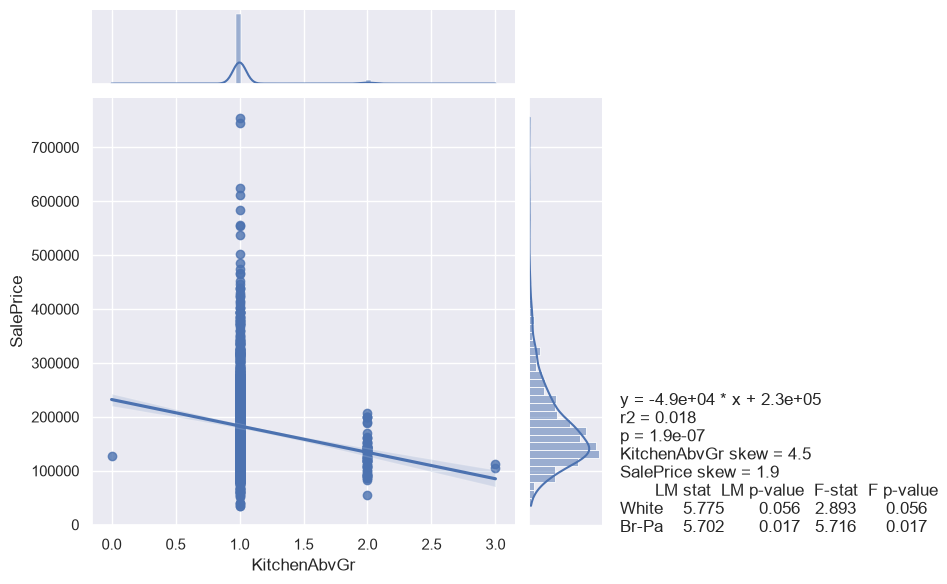

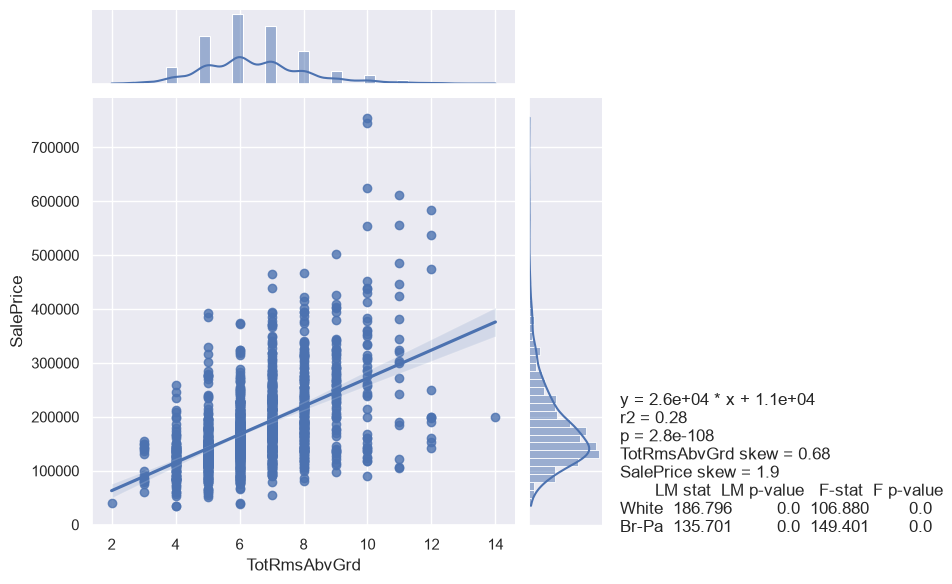

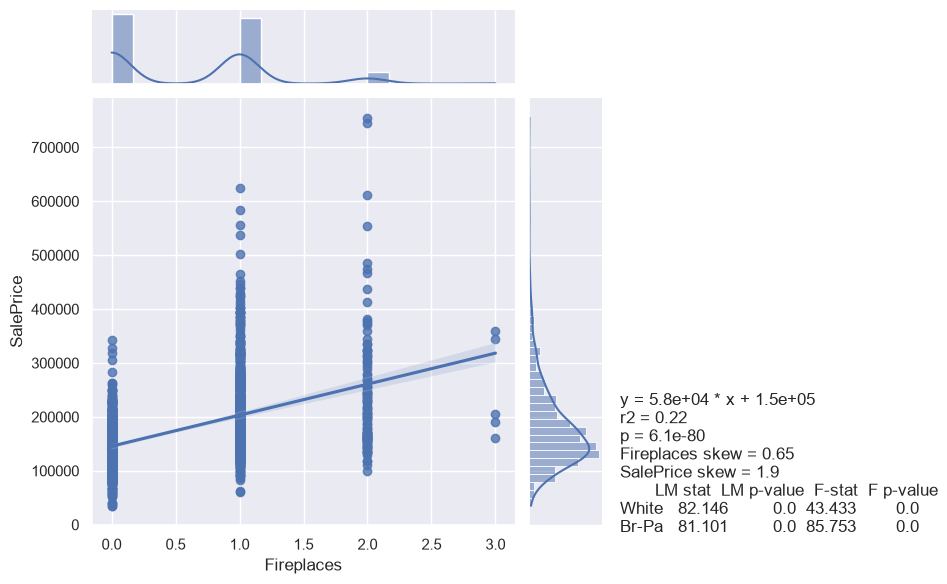

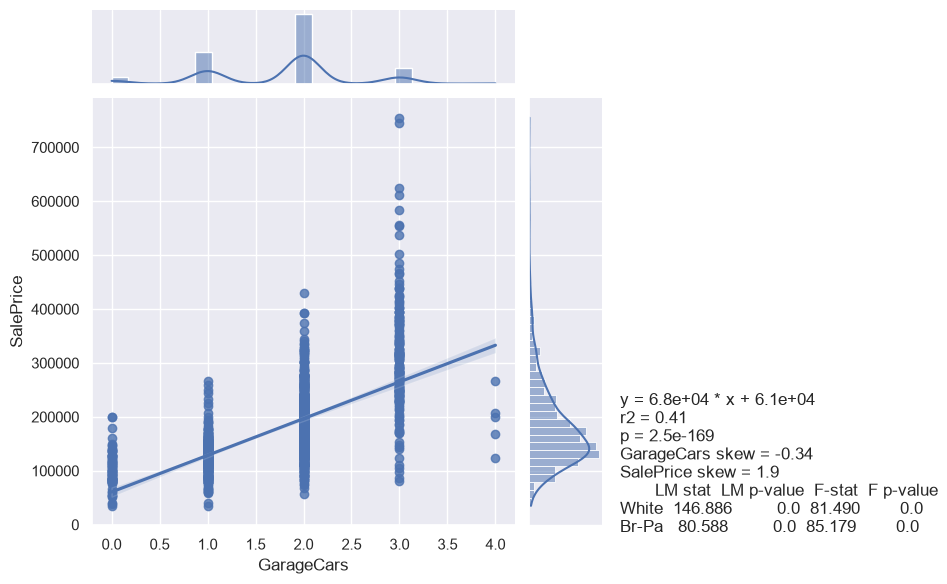

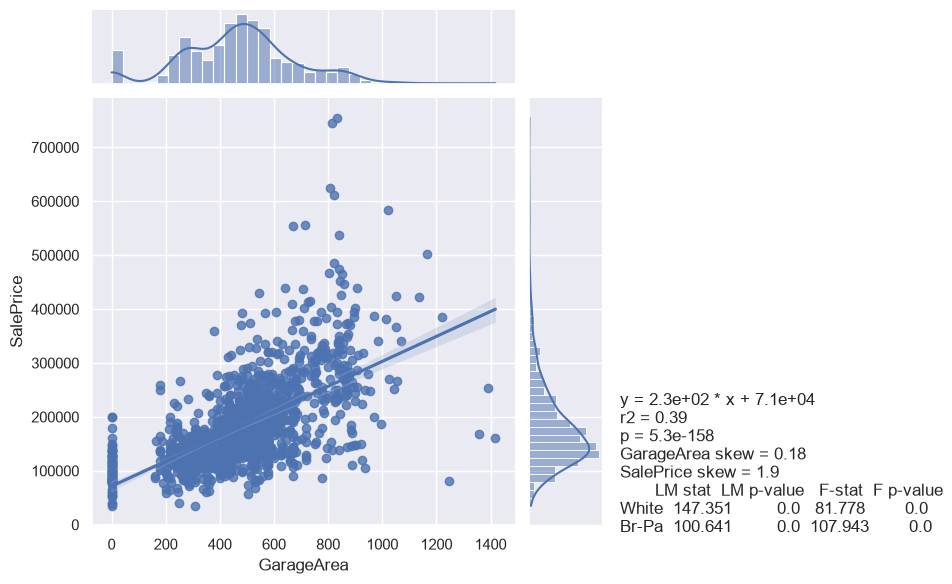

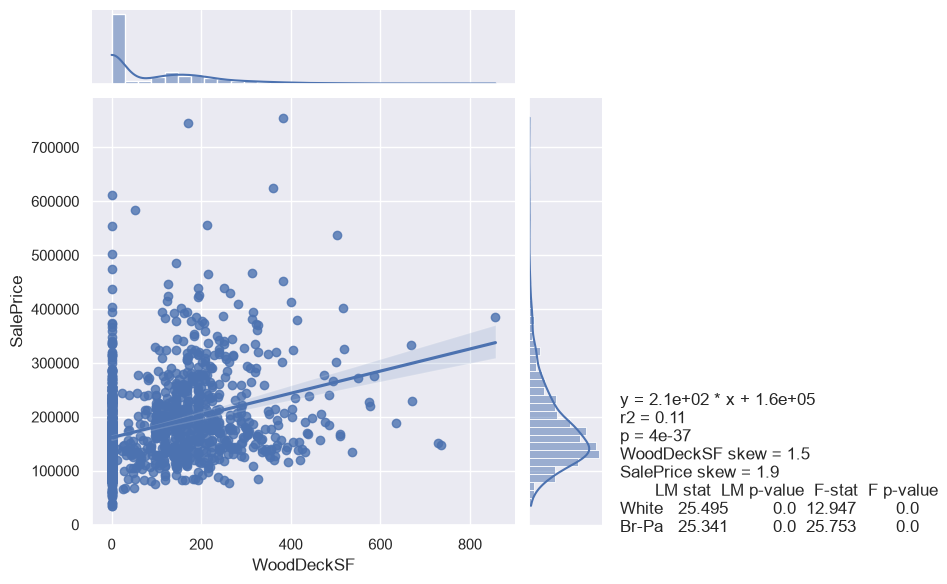

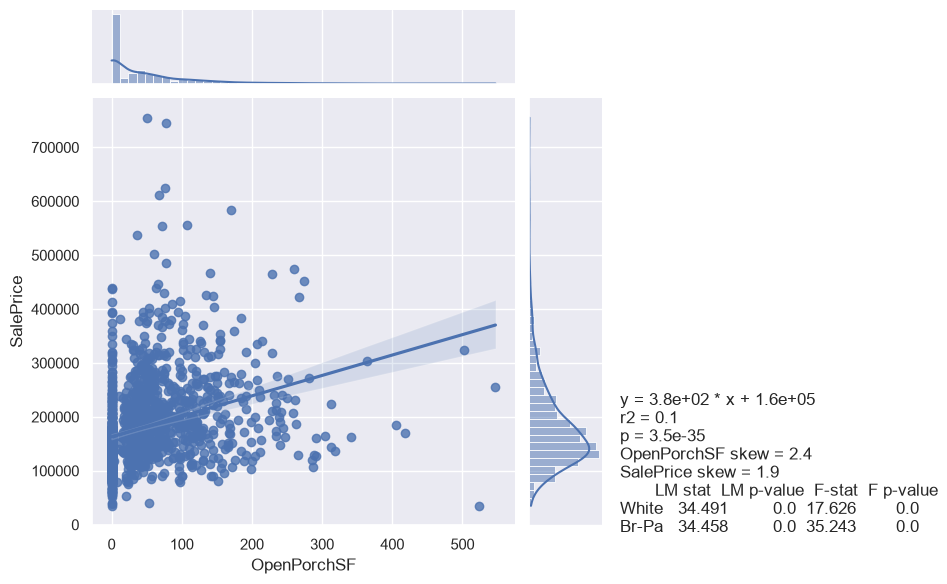

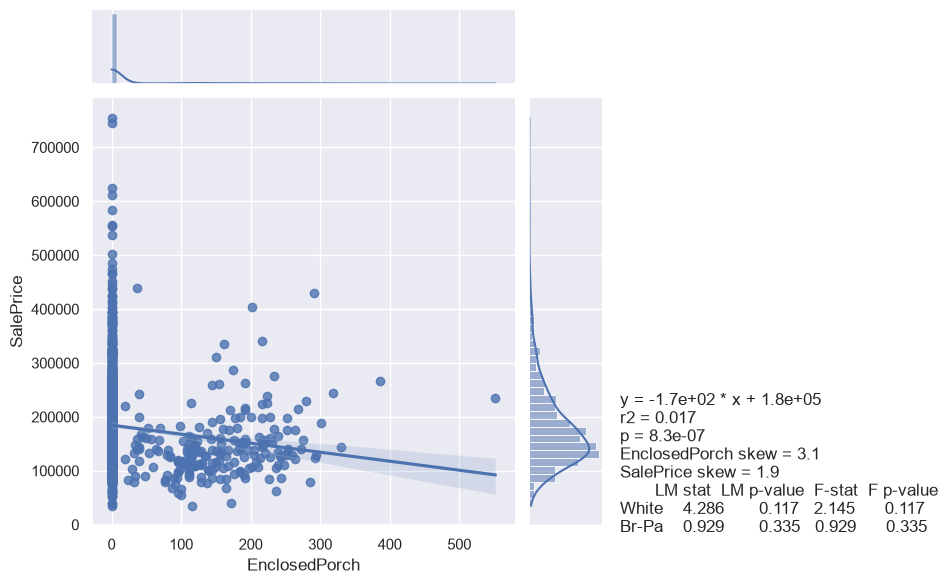

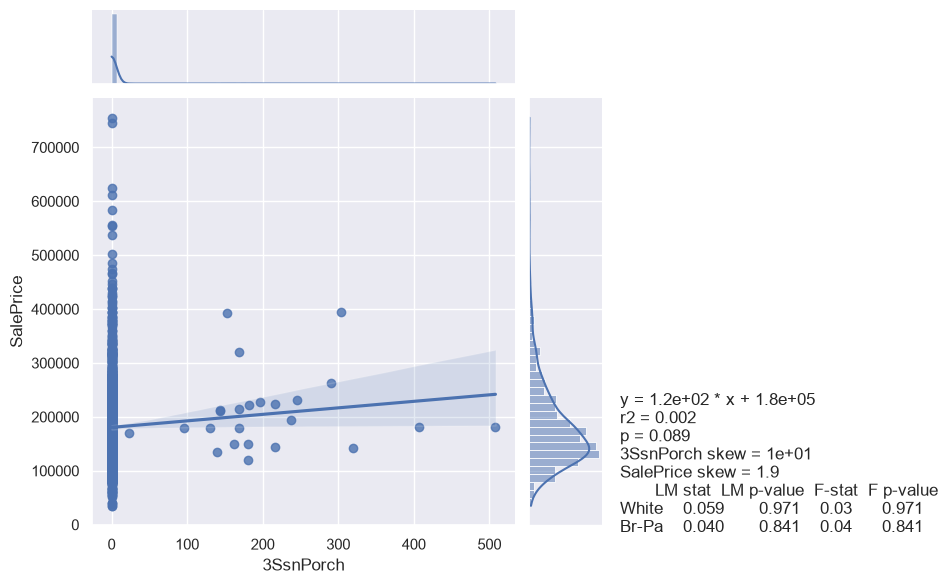

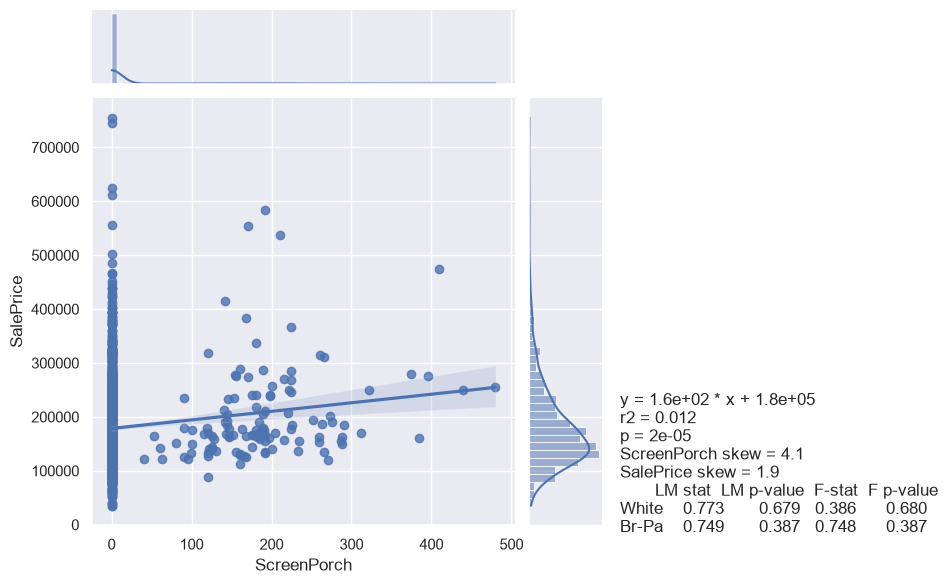

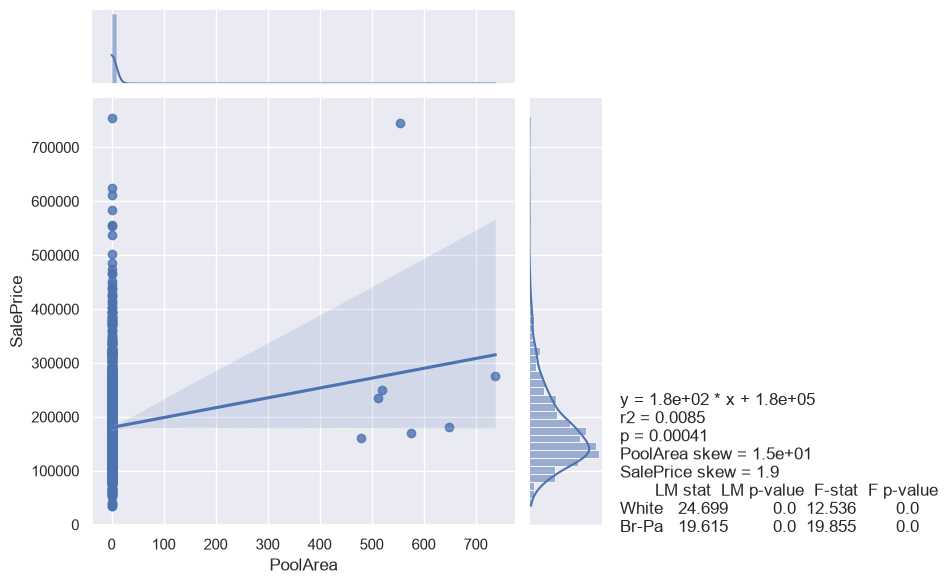

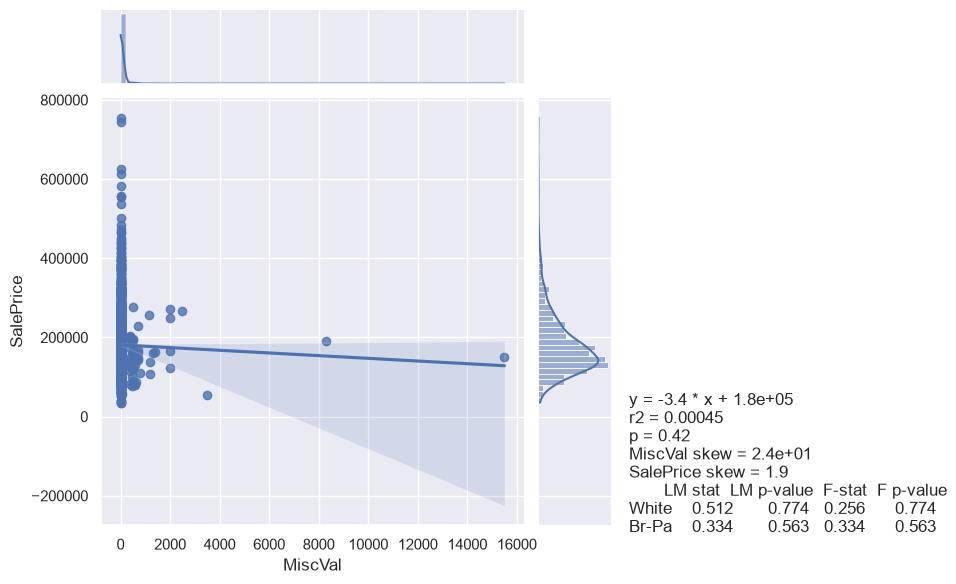

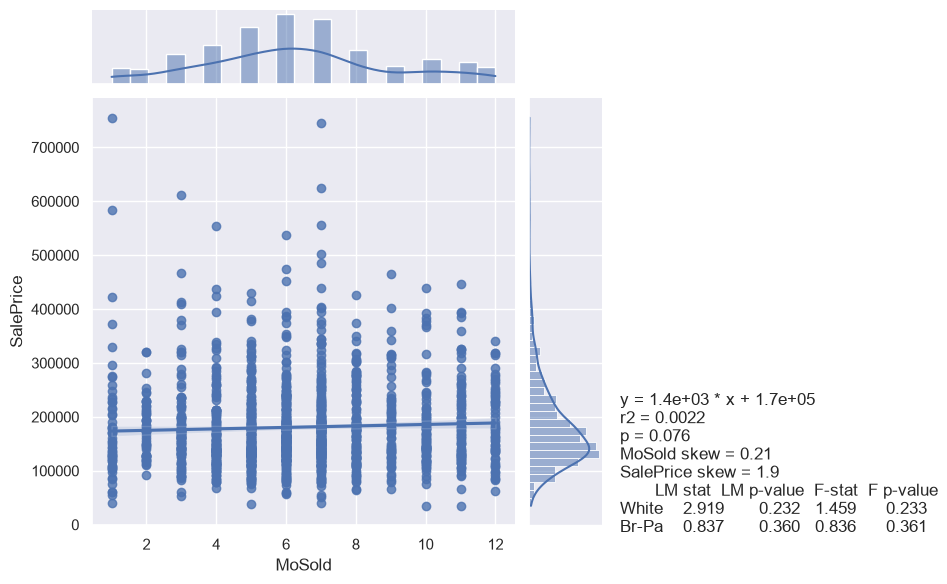

In [13]:
bivstats(df, "SalePrice")

In [60]:
def bar_chart(df, feature, label):
    groups = df[feature].unique()
    df_grouped = df.groupby(feature)
    group_labels = []
    for g in groups:
        g_list = df_grouped.get_group(g)
        group_labels.append(g_list[label])

    # ANOVA
    oneway = stats.f_oneway(*group_labels)

    # T-tests with Bonferroni correction
    unique_groups = df[feature].unique()
    ttests = []

    for i, group in enumerate(unique_groups):
        for i2, group_2 in enumerate(unique_groups):
            if i2 > i:
                type_1 = df[df[feature] == group]
                type_2 = df[df[feature] == group_2]
                t, p = stats.ttest_ind(type_1[label], type_2[label])
                ttests.append([group, group_2, t.round(4), p.round(4)])

    p_threshold = 0.05 / len(ttests) # Bonferroni corrected p-value determined

    # Descriptive Statistics for Diagram
    textstr = "ANOVA \n"
    textstr += f"F: {oneway[0]:.2} \n"
    textstr += f"F: {oneway[1]:.2} \n\n"
    textstr += "Sig. comparisons (Bonferroni-corrected) \n"

    for ttest in ttests:
        if ttest[3] <= p_threshold:
            textstr += f"{ttest[0]} - {ttest[1]} - {ttest[2]} - {ttest[3]} \n"

    means = df.groupby(feature)[label].mean().round(2)

    ax = sns.barplot(x=df[feature], y=df[label], hue=df[feature])#, palette="pastel")
    plt.title(label + " by " + feature)
    
    ax.text(1, 0.1, textstr, fontsize=12, transform=plt.gcf().transFigure)
    plt.show()

There must be more than 1 case per group to perform a t-test

If there is a problem for generating t-test result, we can encounter dividing by 0 error when we perform Bonferroni correction. So, be careful

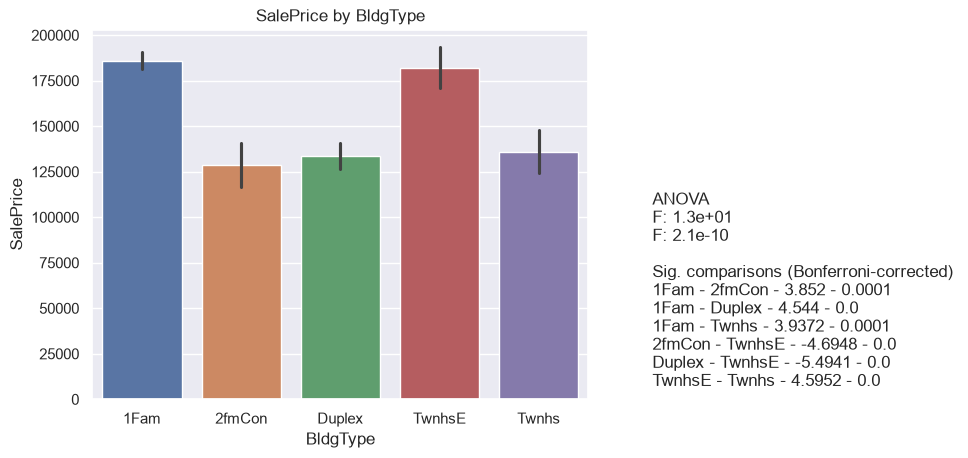

In [61]:
bar_chart(df, "BldgType", "SalePrice")